# Demo de `toolbox_ml`

Este notebook demuestra el uso de todas las funciones del paquete `toolbox_ml.eda.core` sobre un dataset real: el clásico dataset del Titanic.

**Requisito previo:** el paquete debe estar instalado en modo editable desde la raíz del repositorio:

```bash
pip install -r requirements.txt
pip install -e .
```

In [1]:
import pandas as pd

from toolbox_ml.eda.core import (
    describe_df,
    tipifica_variables,
    get_features_num_regression,
    plot_features_num_regression,
    get_features_cat_regression,
    plot_features_cat_regression,
    detect_outliers,
)

df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. `describe_df`

Genera un resumen rápido de cada columna: tipo de dato, porcentaje de nulos, número de valores únicos y porcentaje de cardinalidad.

In [2]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
survived,int64,0.00,2,0.22
pclass,int64,0.00,3,0.34
sex,str,0.00,2,0.22
age,float64,19.87,88,9.88
sibsp,int64,0.00,7,0.79
parch,int64,0.00,7,0.79
fare,float64,0.00,248,27.83
embarked,str,0.22,3,0.34
class,str,0.00,3,0.34
who,str,0.00,3,0.34


## 2. `tipifica_variables`

Sugiere automáticamente qué tipo de variable es cada columna (Binaria, Categórica, Numérica Continua o Numérica Discreta), en función de dos umbrales que definimos nosotros.

In [3]:
tipifica_variables(df, umbral_categoria=10, umbral_continua=30.0)

,nombre_variable,tipo_sugerido
0,survived,Binaria
1,pclass,Categórica
2,sex,Binaria
3,age,Numérica Discreta
4,sibsp,Categórica
5,parch,Categórica
6,fare,Numérica Discreta
7,embarked,Categórica
8,class,Categórica
9,who,Categórica


## 3. `get_features_num_regression` y `plot_features_num_regression`

Usamos `fare` (precio del billete) como variable objetivo numérica de ejemplo, y buscamos qué otras columnas numéricas están correlacionadas con ella.

In [4]:
columnas_num_relevantes = get_features_num_regression(
    df, target_col="fare", umbral_corr=0.1, pvalue=0.05
)
print("Columnas numéricas seleccionadas:", columnas_num_relevantes)

Columnas numéricas seleccionadas: ['survived', 'pclass', 'sibsp', 'parch']


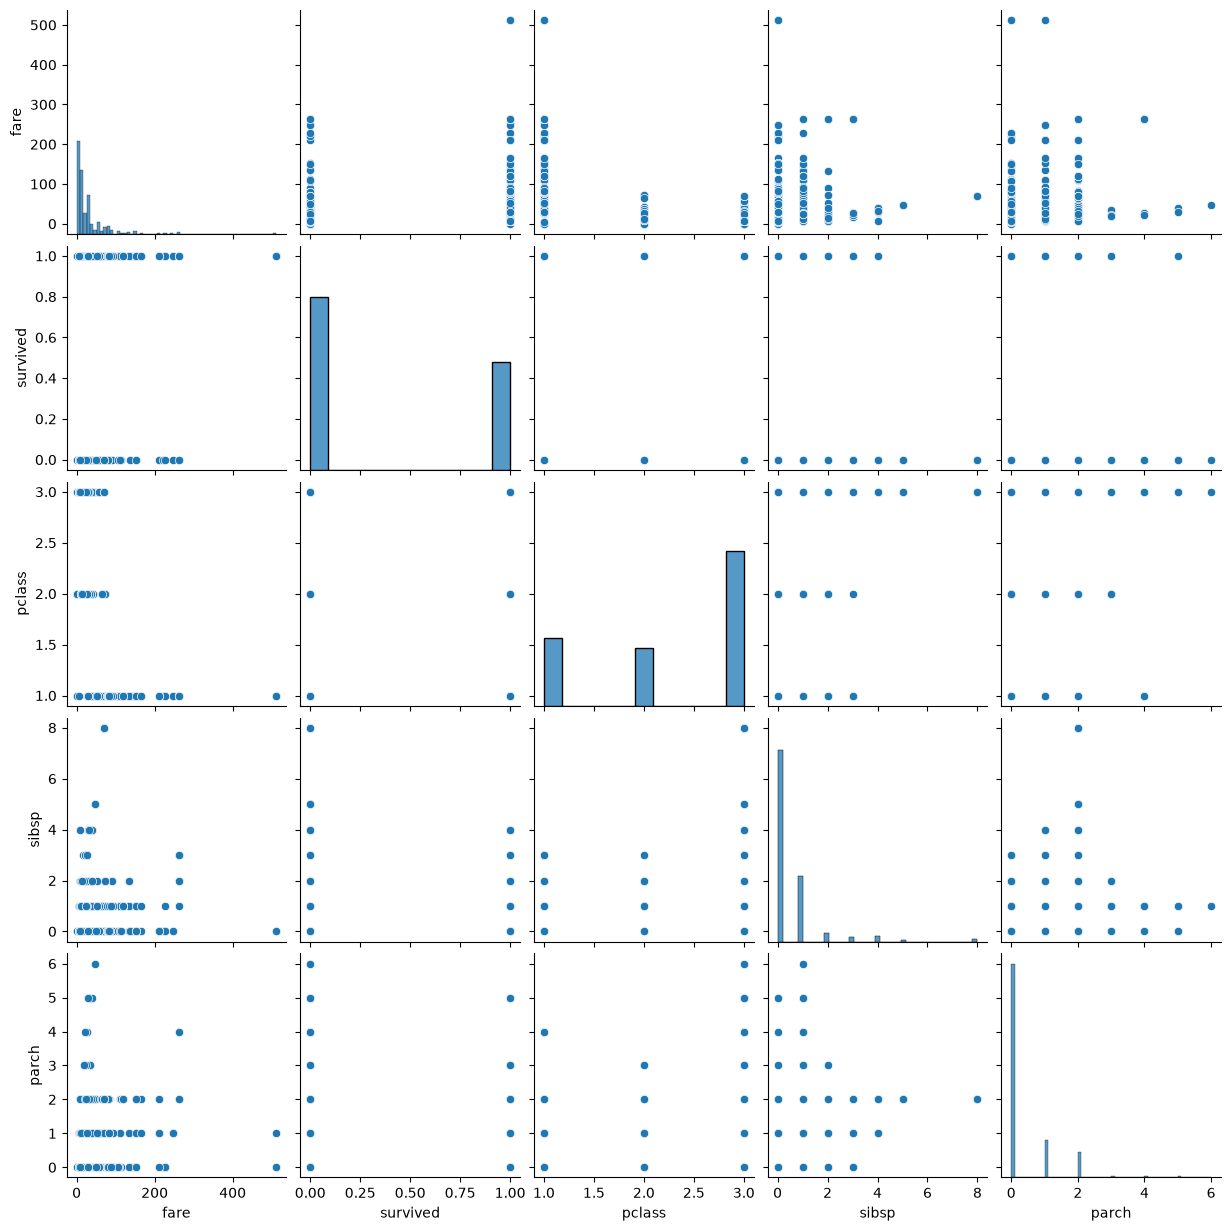

In [5]:
# plot_features_num_regression repite el filtro y además pinta un pairplot
_ = plot_features_num_regression(
    df, target_col="fare", umbral_corr=0.1, pvalue=0.05
)

## 4. `get_features_cat_regression` y `plot_features_cat_regression`

Buscamos qué columnas categóricas (`sex`, `embarked`, `class`, `who`...) tienen una relación estadísticamente significativa con `fare`.

In [6]:
columnas_cat_relevantes = get_features_cat_regression(df, target_col="fare", pvalue=0.05)
print("Columnas categóricas seleccionadas:", columnas_cat_relevantes)

Columnas categóricas seleccionadas: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


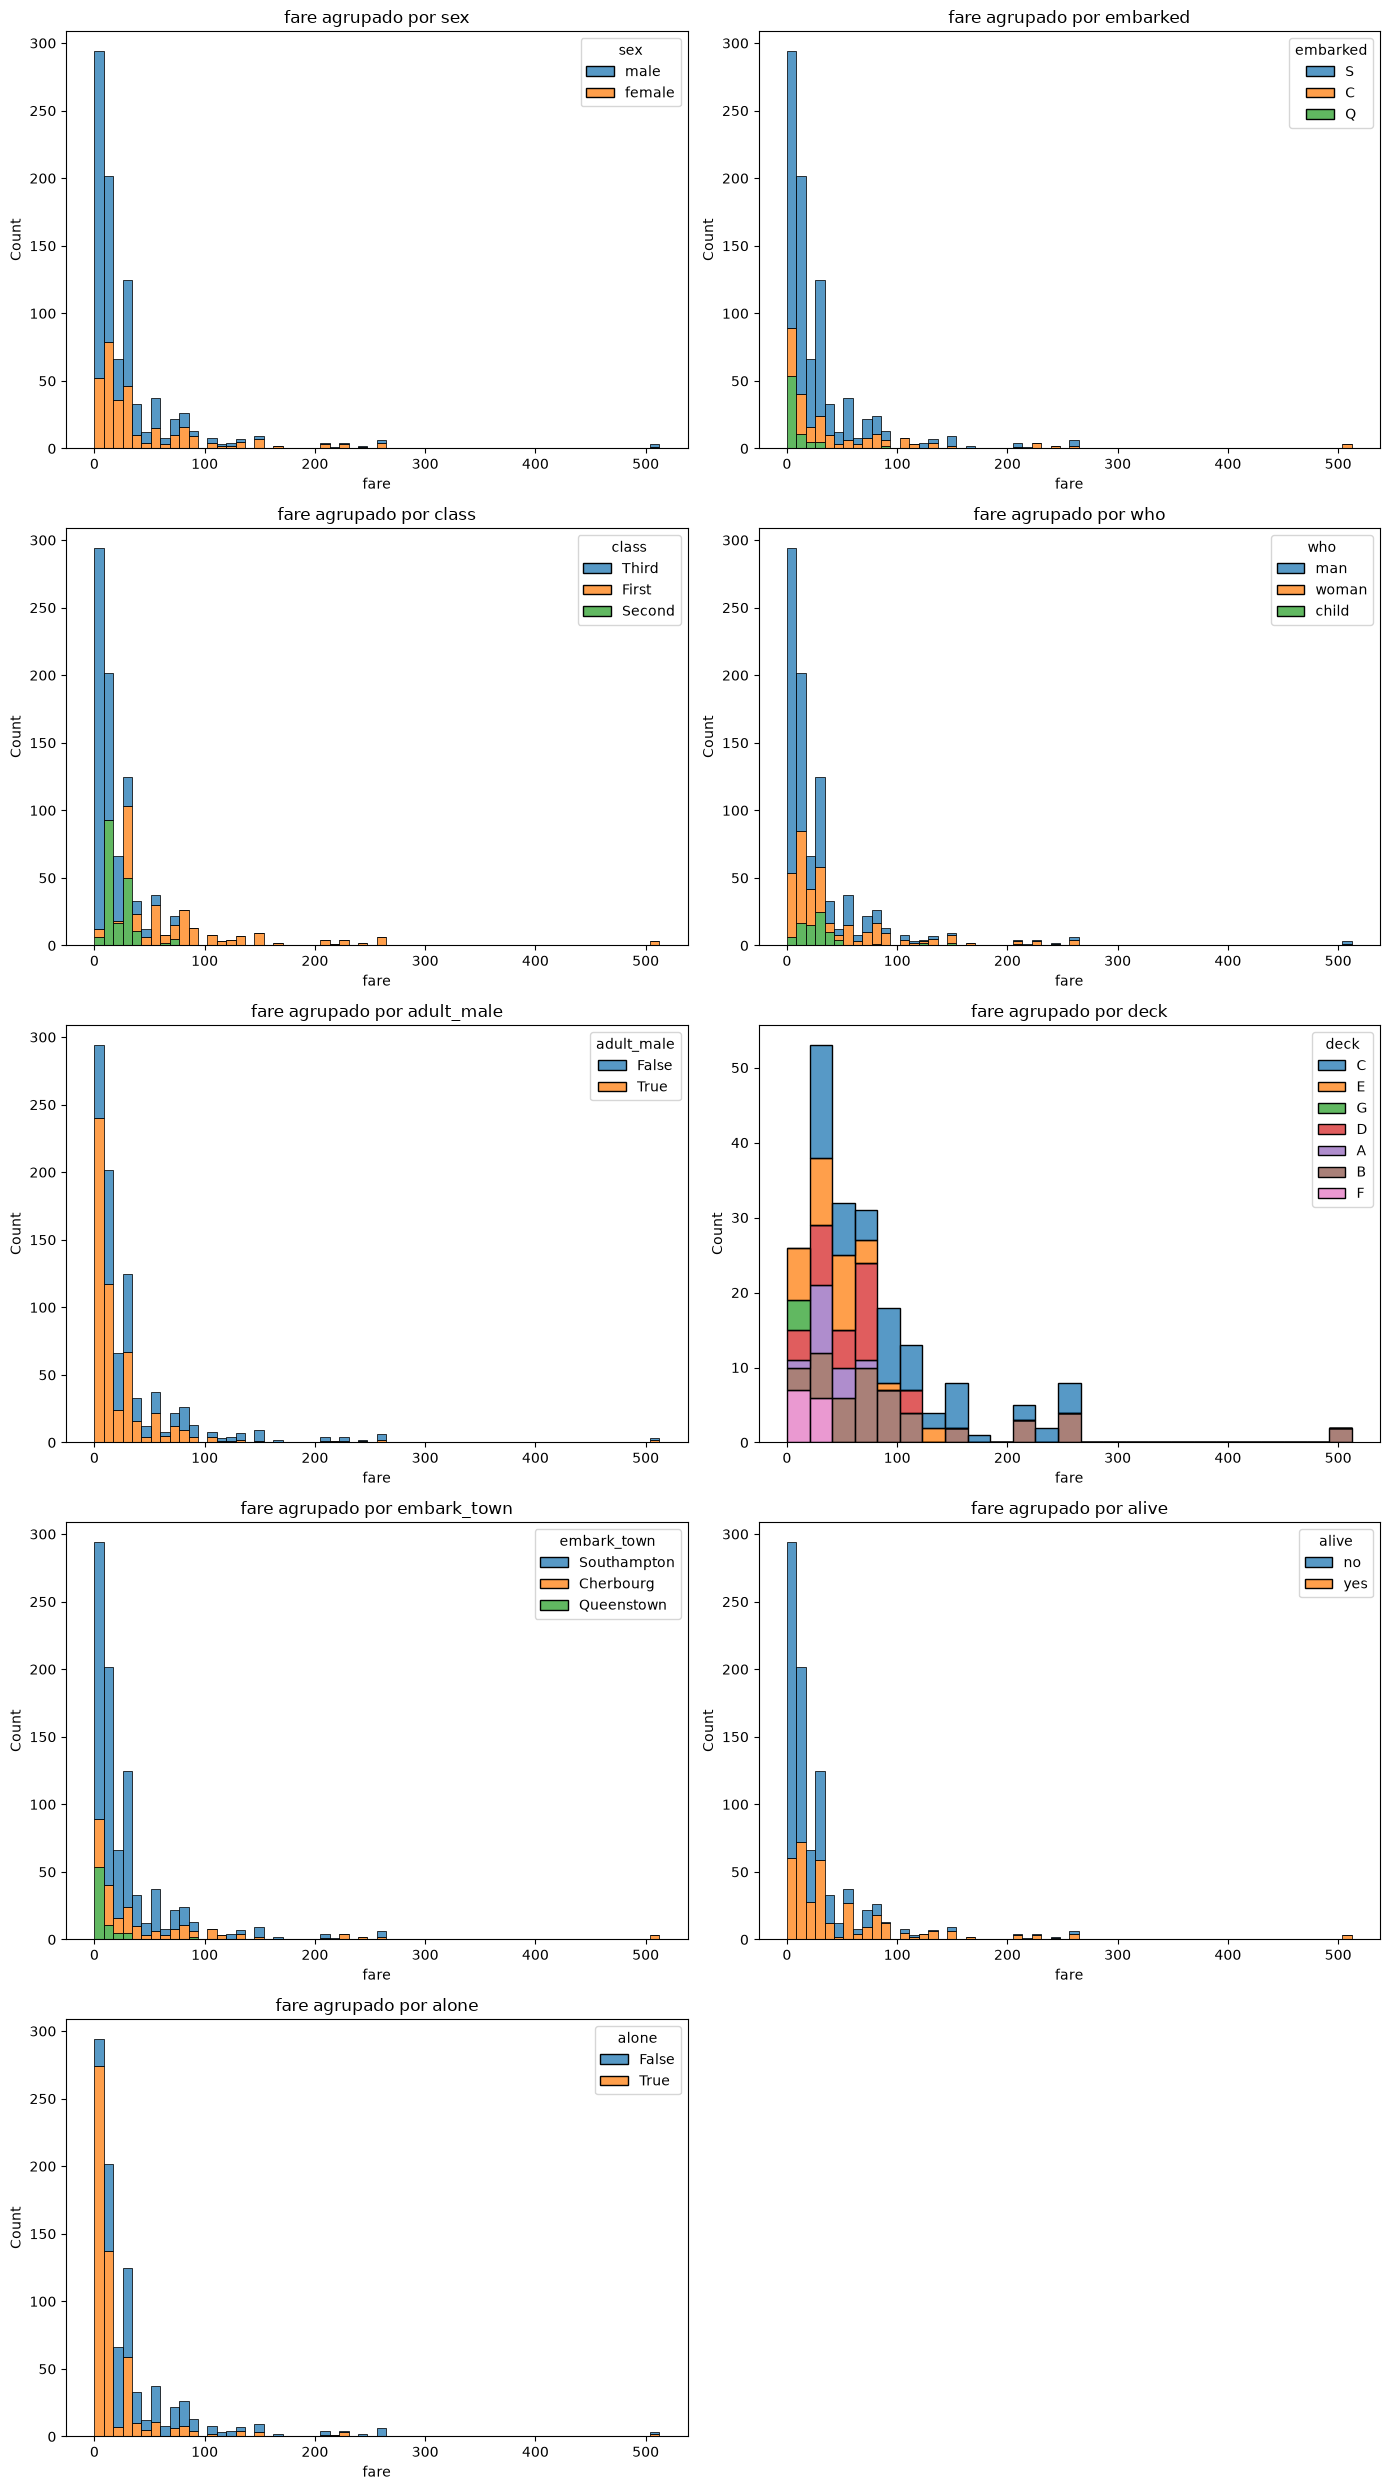

In [7]:
_ = plot_features_cat_regression(
    df, target_col="fare", pvalue=0.05, with_individual_plot=False
)

## 5. BONUS: `detect_outliers`

Detectamos outliers en las columnas numéricas usando dos métodos (IQR y Z-score) y comparamos cuántos detecta cada uno.

In [8]:
outliers = detect_outliers(df)

for columna, resultado in outliers.items():
    print(
        f"{columna:10s} | IQR: {resultado['iqr']['n_outliers']:3d} "
        f"({resultado['iqr']['porcentaje']:5.2f}%) | "
        f"Z-score: {resultado['zscore']['n_outliers']:3d} "
        f"({resultado['zscore']['porcentaje']:5.2f}%)"
    )

survived   | IQR:   0 ( 0.00%) | Z-score:   0 ( 0.00%)
pclass     | IQR:   0 ( 0.00%) | Z-score:   0 ( 0.00%)
age        | IQR:  11 ( 1.23%) | Z-score:   2 ( 0.22%)
sibsp      | IQR:  46 ( 5.16%) | Z-score:  30 ( 3.37%)
parch      | IQR: 213 (23.91%) | Z-score:  15 ( 1.68%)
fare       | IQR: 116 (13.02%) | Z-score:  20 ( 2.24%)


In [9]:
# Ejemplo: primeros índices de los outliers detectados en 'fare' por IQR
outliers["fare"]["iqr"]["indices"][:10]

[1, 27, 31, 34, 52, 61, 62, 72, 88, 102]

## Conclusión

Con estas siete funciones se cubre un flujo de EDA razonablemente completo: descripción y tipificación automática de variables, selección de features numéricas y categóricas relevantes para un problema de regresión (con su visualización correspondiente), y detección de outliers. Todo el código vive en `toolbox_ml/eda/core.py`, está testeado en `tests/test_core.py` y es reutilizable en cualquier notebook o script simplemente con:

```python
from toolbox_ml.eda.core import describe_df, tipifica_variables, ...
```